In [106]:
### imports ###


import numpy as np 
import pandas as pd 
import sklearn 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [109]:
### load the data ###


data = pd.read_csv('gender_classification_v7.csv')
data.shape

(5001, 8)

In [90]:
data

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [92]:
def pre_process_data(df):
    data["gender"] = df["gender"].map({'Female' : 0, 'Male' : 1})
    return df

data = pre_process_data(data)

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 312.7 KB


In [94]:
X = data.drop(columns=['gender'])
y = data.gender

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 

In [95]:
model= LogisticRegression()
model.fit(X_train, y_train)
y_prediction = model.predict(X_test)

In [96]:
print("Logistic Regression: ")
print(classification_report(y_test, y_prediction))

Logistic Regression: 
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       496
           1       0.97      0.96      0.97       505

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001



In [97]:

gender_map = {1: 'Male', 0: 'Female'}
decoded_predictions = [gender_map[pred] for pred in y_prediction]

decoded_predictions = pd.Series(y_prediction).map(gender_map)

decoded_actuals = pd.Series(y_test).map(gender_map)
Comparison_df = pd.DataFrame({
    'Actual' : decoded_actuals,
    'Prediction' : decoded_predictions
})

print(Comparison_df.head())


  Actual Prediction
0    NaN       Male
1    NaN     Female
2   Male       Male
3    NaN       Male
4    NaN     Female


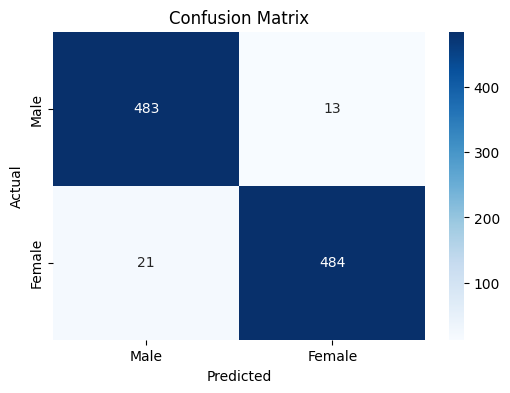

In [110]:
cm = confusion_matrix(y_test, y_prediction)
labels = ['Male', 'Female'] 

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()